In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Superstore Sales

2. Identify the Customer IDs whose single largest order’s profit was greater than the overall average profit of all orders in their respective Region.

3. Find the Ship Mode that has the highest average Shipping Cost but only consider orders where the Sales amount was below the median Sales amount of the entire dataset.

In [2]:
df1 = pd.read_csv('/content/drive/MyDrive/Datasets/Sales_Dataset.csv.csv', encoding = 'Latin1')
df1.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [3]:
df1.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df1.shape

(9994, 21)

Q1: Customers with largest order profit > regional average profit

In [5]:
# Calculate the largest profit for each customer
customer_max = df1.groupby(['Customer ID', 'Region'])['Profit'].max()#.reset_index()
display(customer_max.head())

Customer ID  Region 
AA-10315     Central     90.7350
             East         7.0218
             West       252.5880
AA-10375     Central     50.9898
             East        29.2450
Name: Profit, dtype: float64

In [6]:
# Calculate the largest profit for each customer
customer_max = df1.groupby(['Customer ID', 'Region'])['Profit'].max().reset_index()
display(customer_max.head())

,Customer ID,Region,Profit
0,AA-10315,Central,90.7350
1,AA-10315,East,7.0218
2,AA-10315,West,252.5880
3,AA-10375,Central,50.9898
4,AA-10375,East,29.2450


In [7]:
"""
Identify Customer IDs whose single largest order's profit was greater than
the overall average profit of all orders in their respective Region.
"""
# Calculate regional average profit
regional_avg = df1.groupby('Region')['Profit'].mean().reset_index()
regional_avg.columns = ['Region', 'regional_avg_profit']  #Renaming the columns
regional_avg

,Region,regional_avg_profit
0,Central,17.092709
1,East,32.135808
2,South,28.857673
3,West,33.849032


In [8]:
# Find each customer's maximum order profit
customer_max = df1.groupby(['Customer ID', 'Region'])['Profit'].max().reset_index()
customer_max.head()

,Customer ID,Region,Profit
0,AA-10315,Central,90.7350
1,AA-10315,East,7.0218
2,AA-10315,West,252.5880
3,AA-10375,Central,50.9898
4,AA-10375,East,29.2450


In [9]:
# Merge and filter
result = customer_max.merge(regional_avg, on='Region')
result.head()

,Customer ID,Region,Profit,regional_avg_profit
0,AA-10315,Central,90.7350,17.092709
1,AA-10315,East,7.0218,32.135808
2,AA-10315,West,252.5880,33.849032
3,AA-10375,Central,50.9898,17.092709
4,AA-10375,East,29.2450,32.135808


In [10]:
qualified_customers = result[result['Profit'] > result['regional_avg_profit']]
qualified_customers.head(5)

,Customer ID,Region,Profit,regional_avg_profit
0,AA-10315,Central,90.7350,17.092709
2,AA-10315,West,252.5880,33.849032
3,AA-10375,Central,50.9898,17.092709
5,AA-10375,South,114.9954,28.857673
7,AA-10480,Central,163.1898,17.092709


In [11]:
l1 = qualified_customers['Customer ID'].tolist()
print(l1[:4])
print(len(l1))

# Explanation: Groups by region to find average profit, then by customer to find max profit,
# finally compares each customer's max profit against their region's average.

['AA-10315', 'AA-10315', 'AA-10375', 'AA-10375']
1432


Q.2 Find the Ship Mode that has the highest average Shipping Cost but only consider orders where the Sales amount was below the median Sales amount of the entire dataset.

Find the index of the maximum value in each column        
print(df.idxmax(axis=0))

Find the index of the maximum value in each row     
print(df.idxmax(axis=1))

In [12]:
# First, calculate the median sales for the entire dataset
median_sales = df1['Sales'].median()

# Filter orders where Sales is below the median
below_median_orders = df1[df1['Sales'] < median_sales].copy()
below_median_orders['Shipping_Cost'] = below_median_orders['Sales'] - below_median_orders['Profit']

# Calculate average shipping cost by Ship Mode
avg_shipping_by_mode = below_median_orders.groupby('Ship Mode')['Shipping_Cost'].mean()
avg_shipping_by_mode

,Shipping_Cost
Ship Mode,
First Class,17.410568
Same Day,16.149219
Second Class,16.286299
Standard Class,16.992906


In [13]:
# Find the Ship Mode with the highest average shipping cost
highest_avg_shipping_mode = avg_shipping_by_mode.idxmax()
highest_avg_shipping_value = avg_shipping_by_mode.max()

print(f"Ship Mode with highest average shipping cost for below-median sales orders: {highest_avg_shipping_mode}")
print(f"Average shipping cost: ${highest_avg_shipping_value:.2f}")

# Show all ship modes with their average shipping costs for comparison
print("\nAll Ship Modes (sorted by average shipping cost):")
print(avg_shipping_by_mode.sort_values(ascending=False))

Ship Mode with highest average shipping cost for below-median sales orders: First Class
Average shipping cost: $17.41

All Ship Modes (sorted by average shipping cost):
Ship Mode
First Class       17.410568
Standard Class    16.992906
Second Class      16.286299
Same Day          16.149219
Name: Shipping_Cost, dtype: float64


In [14]:
# Alternative approach if the above shipping cost calculation doesn't make sense:
# If you need to use a different method to calculate shipping cost, here are some options:

# Option 1: If shipping cost is a fixed percentage of sales
# below_median_orders['Shipping_Cost'] = below_median_orders['Sales'] * 0.1  # 10% example

# Option 2: If you have actual shipping cost data elsewhere
# below_median_orders = below_median_orders.merge(shipping_cost_data, on='Order ID')

2. Iris
3. Calculate the average Petal Length of all flowers whose Sepal Length is in the top 10% of the entire dataset’s Sepal Length values.
4. For each Species, list the Sepal Width value that occurs most frequently (the mode) among samples where the Petal Width is less than the overall average Petal Width.

In [15]:
df2 = pd.read_csv('/content/drive/MyDrive/Datasets/IRIS.csv', encoding = 'Latin1')
df2.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [16]:
df2.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Q.1 Calculate the average Petal Length of all flowers whose Sepal Length is in the top 10% of the entire dataset’s Sepal Length values.

In [17]:
# Calculate 90th percentile threshold for sepal length
threshold = df2['sepal_length'].quantile(0.9)

# Filter flowers with sepal length in top 10%
top_sepal_flowers = df2[df2['sepal_length'] >= threshold]
top_sepal_flowers.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,Iris-versicolor
52,6.9,3.1,4.9,1.5,Iris-versicolor
102,7.1,3.0,5.9,2.1,Iris-virginica
105,7.6,3.0,6.6,2.1,Iris-virginica
107,7.3,2.9,6.3,1.8,Iris-virginica


In [18]:
# Calculate average petal length
avg_petal_length = top_sepal_flowers['petal_length'].mean()
avg_petal_length

# Explanation: Uses quantile to find 90th percentile of sepal length, filters dataset,
# and calculates mean petal length for the filtered subset.

np.float64(5.96470588235294)

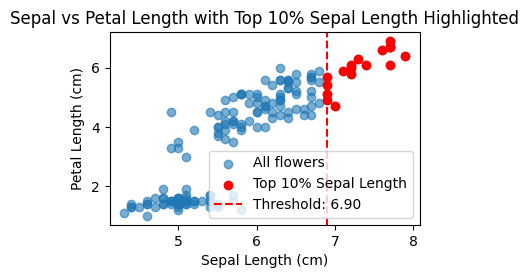

In [19]:
# Visualization
plt.figure(figsize=(4, 2.5))
plt.scatter(df2['sepal_length'], df2['petal_length'], alpha=0.6, label='All flowers')
plt.scatter(top_sepal_flowers['sepal_length'], top_sepal_flowers['petal_length'],
          color='red', label='Top 10% Sepal Length')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.2f}')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Sepal vs Petal Length with Top 10% Sepal Length Highlighted')
plt.legend()
plt.show()

Q.2 For each Species, list the Sepal Width value that occurs most frequently (the mode) among samples where the Petal Width is less than the overall average Petal Width.

Since .mode() can return multiple values if there are ties, we take the first one with .iloc[0]

The result shows the most frequent sepal width for each species within the below-average petal width subset


In [20]:
import statistics as stats

# Calculate overall average petal width
avg_petal_width = df2['petal_width'].mean()

# Filter flowers with below-average petal width
low_petal_width = df2[df2['petal_width'] < avg_petal_width]

# Find mode sepal width for each species
mode_sepal_width = low_petal_width.groupby('species')['sepal_width'].apply(lambda x: x.mode().iloc[0]) # if len(x) > 0 else None)
mode_sepal_width

,sepal_width
species,
Iris-setosa,3.4
Iris-versicolor,2.4


In [21]:
avg_petal_width = df2['petal_width'].mean()
low_petal_width = df2[df2['petal_width'] < avg_petal_width]

# Find mode sepal width for each species
mode_sepal_width = low_petal_width.groupby('species')['sepal_width'].agg(lambda x: x.mode().iloc[0])
mode_sepal_width

,sepal_width
species,
Iris-setosa,3.4
Iris-versicolor,2.4


3. Titanic
5. Find the average fare for passengers who survived, but only if that average fare is higher than the average fare paid by passengers who did not survive.
6. Determine the Embarked port that had the highest survival rate for passengers whose Age was below the overall median Age of all passengers.

In [22]:
df3 = pd.read_csv('/content/drive/MyDrive/Datasets/titantic.csv', encoding = 'Latin1')
df3.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [23]:
df3.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Find the average fare for passengers who survived, but only if that average fare is higher than the average fare paid by passengers who did not survive.

In [24]:
# Calculate average fare by survival status
avg_fare_by_survival = df3.groupby('Survived')['Fare'].mean()
avg_fare_by_survival

,Fare
Survived,
0,27.527877
1,49.747699


dictionary.get(key, default_value)

avg_fare_by_survival.get(1, -1)

Looks for key 1 in the dictionary avg_fare_by_survival       
If key 1 exists → returns its value (average fare for survivors)       
If key 1 doesn't exist → returns the default value -1

In [25]:
survivor_avg = avg_fare_by_survival.get(1,-1)  # Survived = 1
non_survivor_avg = avg_fare_by_survival.get(0, 0)  # Did not survive = 0  #If key 0 doesn't exist → returns the default value 0
survivor_avg, non_survivor_avg

(np.float64(49.747698684210526), np.float64(27.527876981132074))

In [26]:
# Return survivor average only if it's higher
result = survivor_avg if survivor_avg > non_survivor_avg else None
result

np.float64(49.747698684210526)

In [27]:
# Calculate average fares for both groups
avg_fare_survived = df3[df3['Survived'] == 1]['Fare'].mean()
avg_fare_not_survived = df3[df3['Survived'] == 0]['Fare'].mean()

# Only return survivor average if it's higher
result = avg_fare_survived if avg_fare_survived > avg_fare_not_survived else None
result

np.float64(49.747698684210526)

Q.2 Determine the Embarked port that had the highest survival rate for passengers whose Age was below the overall median Age of all passengers

The .dropna(subset=['Embarked']) part is used to remove rows where the 'Embarked' column has missing values.

Why this is important:
The Embarked column indicates the port where the passenger boarded (C = Cherbourg, Q = Queenstown, S = Southampton)

If there are missing values (NaN) in the Embarked column, they would create problems when we try to group by this column

Grouping by a column with NaN values would create an additional "NaN group" which we don't want to include in our analysis

In [28]:
# Calculate median age (handling missing values)
median_age = df3['Age'].median()

# Filter young passengers
young_passengers = df3[df3['Age'] < median_age].dropna(subset=['Embarked'])
young_passengers.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [29]:
# Calculate survival rate by embarkation port
survival_rates = young_passengers.groupby('Embarked')['Survived'].mean()
survival_rates

,Survived
Embarked,
C,0.444444
Q,0.545455
S,0.358974


In [30]:
# Find port with highest survival rate
best_port = survival_rates.idxmax()
highest_rate = survival_rates.max()
best_port, highest_rate

('Q', 0.5454545454545454)

4. Wine Quality
7. Find the ID of the wine that has the highest Density among wines whose Quality score falls into the top 20% of all distinct quality scores observed in the dataset.
8. Identify the Fixed Acidity value that is furthest from the overall dataset’s average Fixed Acidity, considering only samples where the Alcohol content is greater than the average Alcohol content for wines with Quality = 8.

In [31]:
df4 = pd.read_csv('/content/drive/MyDrive/Datasets/WineQT.csv', encoding = 'Latin1')
df4.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2


In [32]:
df4.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Q.1 Find the ID of the wine that has the highest Density among wines whose Quality score falls into the top 20% of all distinct quality scores observed in the dataset.

In [33]:
# Step 1: Get top 20% quality threshold
top_quality = df4['quality'].quantile(0.8)

# Step 2: Filter for high quality wines
high_quality = df4[df4['quality'] >= top_quality]
high_quality.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
12,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.9969,3.30,0.75,10.5,7,16
13,7.9,0.32,0.51,1.8,0.341,17.0,56.0,0.9969,3.04,1.08,9.2,6,19


In [34]:
# Step 3: Find row with max density and get its ID
max_density_row = high_quality[high_quality['density'] == high_quality['density'].max()]
max_density_row

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1022,10.2,0.54,0.37,15.4,0.214,55.0,95.0,1.00369,3.18,0.77,9.0,6,1434


In [35]:
wine_idx = max_density_row.index[0]  # or max_density_row['id'].iloc[0] if you have ID column
print(wine_idx)
max_density_row['Id']

1022


,Id
1022,1434


2. .idxmax()
This method finds the index label of the maximum value in the Series

Example: If row with index 42 has the highest density, it returns 42

3. high_quality_wines.loc[ ... ]
.loc[] is used to select rows by their index label

So high_quality_wines.loc[42] would select the entire row with index 42

In [36]:
# Find top 20% quality threshold
quality_threshold = df4['quality'].quantile(0.8)

# Filter high-quality wines
high_quality_wines = df4[df4['quality'] >= quality_threshold]

highest_density_wine = high_quality_wines.loc[high_quality_wines['density'].idxmax()]
wine_id = highest_density_wine['Id']
wine_id

np.float64(1434.0)

Q.2 Identify the Fixed Acidity value that is furthest from the overall dataset’s average Fixed Acidity, considering only samples where the Alcohol content is greater than the average Alcohol content for wines with Quality = 8.

In [37]:
# Calculate average alcohol for quality 8 wines
#avg_alcohol_quality8 = df4[df4['quality'] == 8]['alcohol'].mean()

quality8 = df4[df4['quality'] == 8]
avg_alcohol_quality8 = quality8['alcohol'].mean()
avg_alcohol_quality8

np.float64(11.9375)

In [38]:
# Calculate overall average fixed acidity
overall_avg_fixed_acidity = df4['fixed acidity'].mean()
print(overall_avg_fixed_acidity)

# Filter wines with high alcohol from quality 8 group
high_alcohol_wines = df4[(df4['alcohol'] > avg_alcohol_quality8)]
high_alcohol_wines.head()

8.311111111111112


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
32,4.6,0.52,0.15,2.1,0.054,8.0,65.0,0.99340,3.90,0.56,13.1,4,45
91,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5,131
96,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,142
98,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,144
148,9.7,0.53,0.60,2.0,0.039,5.0,19.0,0.99585,3.30,0.86,12.4,6,210


In [39]:
# Find fixed acidity value furthest from overall average
high_alcohol_wines = high_alcohol_wines.copy()
high_alcohol_wines['distance_from_avg'] = abs(high_alcohol_wines['fixed acidity'] - overall_avg_fixed_acidity)
high_alcohol_wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,distance_from_avg
32,4.6,0.52,0.15,2.1,0.054,8.0,65.0,0.99340,3.90,0.56,13.1,4,45,3.711111
91,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5,131,2.711111
96,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,142,3.111111
98,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,144,3.111111
148,9.7,0.53,0.60,2.0,0.039,5.0,19.0,0.99585,3.30,0.86,12.4,6,210,1.388889


In [40]:
furthest_acidity = high_alcohol_wines.loc[high_alcohol_wines['distance_from_avg'].idxmax()]
furthest_acidity

,462
fixed acidity,15.900000
volatile acidity,0.360000
citric acid,0.650000
residual sugar,7.500000
chlorides,0.096000
free sulfur dioxide,22.000000
total sulfur dioxide,71.000000
density,0.997600
pH,2.980000
sulphates,0.840000


In [41]:
furthest_acidity['fixed acidity'], overall_avg_fixed_acidity, furthest_acidity['distance_from_avg']

(np.float64(15.9),
 np.float64(8.311111111111112),
 np.float64(7.588888888888889))

5. Adult Census Income
9. Identify all workclasses where the percentage of individuals earning >50K is strictly higher than the overall dataset’s percentage of people earning >50K.
10. Find the average Capital Gain for individuals who are in the top 5% of the hours-per-week ranking for their specific Education level.

In [42]:
df5 = pd.read_csv('/content/drive/MyDrive/Datasets/adult_census.csv', encoding = 'Latin1')
df5.sample(7)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1948,32,Federal-gov,42900,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,15024,0,50,United-States,>50K
21263,47,Private,76034,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,57,United-States,>50K
5160,17,Private,220384,11th,7,Never-married,Adm-clerical,Own-child,White,Male,0,0,15,United-States,<=50K
31272,32,Private,45796,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,60,United-States,<=50K
11909,54,Local-gov,204325,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,52,United-States,<=50K
4112,40,State-gov,150874,Masters,14,Divorced,Exec-managerial,Unmarried,White,Female,1506,0,40,United-States,<=50K
14362,17,Private,140117,10th,6,Never-married,Sales,Own-child,White,Female,0,0,12,United-States,<=50K


In [43]:
df5.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

Identify all workclasses where the percentage of individuals earning >50K is strictly higher than the overall dataset’s percentage of people earning >50K.

In [44]:
# Calculate overall percentage earning >50K
overall_high_earner_pct = (df5['income'] == '>50K').mean()
overall_high_earner_pct

np.float64(0.2408095574460244)

In [45]:
new = df5[df5['income'] == '>50K']

The error occurs because your 'income' column contains string values (like '>50K', '<=50K') instead of numerical values that can be used with the mean() function.

In [46]:
# workclass_stat = new.groupby('workclass')['income'].mean()#.reset_index()
# workclass_stat

In [47]:
# Convert income to binary values (1 for '>50K', 0 for '<=50K')
new['income_numeric'] = new['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Now groupby will work
workclass_stat = new.groupby('workclass')['income_numeric'].mean().reset_index()
workclass_stat.head(2)

/tmp/ipython-input-4075287540.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['income_numeric'] = new['income'].apply(lambda x: 1 if x == '>50K' else 0)


,workclass,income_numeric
0,?,1.0
1,Federal-gov,1.0


In [48]:
# Calculate percentage by workclass
workclass_stats = df5.groupby('workclass').agg({
'income': lambda x: (x == '>50K').mean()
}).reset_index()
workclass_stats.head(3)

,workclass,income
0,?,0.104031
1,Federal-gov,0.386458
2,Local-gov,0.294792


In [49]:
workclass_stats.columns = ['workclass', 'high_earner_pct'] #Renaming columns
workclass_stats.head(3)

,workclass,high_earner_pct
0,?,0.104031
1,Federal-gov,0.386458
2,Local-gov,0.294792


In [50]:
# Filter workclasses with above-average high earner percentage
qualified_workclasses = workclass_stats[
workclass_stats['high_earner_pct'] > overall_high_earner_pct
]
qualified_workclasses

,workclass,high_earner_pct
1,Federal-gov,0.386458
2,Local-gov,0.294792
5,Self-emp-inc,0.557348
6,Self-emp-not-inc,0.284927
7,State-gov,0.271957


In [51]:
qualified_workclasses[['workclass', 'high_earner_pct']]

,workclass,high_earner_pct
1,Federal-gov,0.386458
2,Local-gov,0.294792
5,Self-emp-inc,0.557348
6,Self-emp-not-inc,0.284927
7,State-gov,0.271957


Q.2 Find the average Capital Gain for individuals who are in the top 5% of the hours-per-week ranking for their specific Education level.

In [52]:
# Calculate thresholds for each education level
top_5_thresholds = df5.groupby('education')['hours.per.week'].quantile(0.95)

# Alternative 3 (using map) - Most straightforward
df5['threshold_hours'] = df5['education'].map(top_5_thresholds)
top_5_percent = df5[df5['hours.per.week'] >= df5['threshold_hours']]
df5.head(4)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,threshold_hours
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,60.0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,60.0
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,60.0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,60.0


In [53]:
# Calculate average capital gain
average_capital_gain = top_5_percent['capital.gain'].mean()

print(f"Individuals in top 5%: {len(top_5_percent)}")
print(f"Average Capital Gain: ${average_capital_gain:.2f}")

Individuals in top 5%: 2486
Average Capital Gain: $1990.18


In [54]:
# Method 1: Using groupby and quantile
# Find the top 5% hours-per-week threshold for each education level
top_5_thresholds = df5.groupby('education')['hours.per.week'].quantile(0.95)
top_5_thresholds.sample(5)

,hours.per.week
education,
Bachelors,60.00
7th-8th,60.00
11th,58.00
Some-college,60.00
1st-4th,55.65


In [55]:
# Filter individuals in top 5% of hours for their education level
top_5_percent = df5[df5.apply(lambda row: row['hours.per.week'] >= top_5_thresholds[row['education']], axis=1)]
top_5_percent.sample(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,threshold_hours
2706,25,Private,163620,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,7298,0,84,United-States,>50K,60.0
31382,49,Private,452402,Some-college,10,Separated,Exec-managerial,Unmarried,Black,Female,0,0,60,United-States,<=50K,60.0
17786,53,Self-emp-inc,148532,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,60,United-States,>50K,60.0
7535,34,Private,353213,Assoc-acdm,12,Separated,Craft-repair,Not-in-family,White,Male,0,0,60,United-States,<=50K,60.0
13954,45,Private,234699,HS-grad,9,Married-spouse-absent,Other-service,Unmarried,Black,Female,0,0,60,United-States,>50K,60.0


In [56]:
# More readable version
def is_top_5_percent(row):
    education = row['education']
    hours = row['hours.per.week']
    threshold = top_5_thresholds[education]
    return hours >= threshold

top_5_percent = df5[df5.apply(is_top_5_percent, axis=1)]
top_5_percent.sample(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,threshold_hours
685,49,Self-emp-inc,213140,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1902,60,United-States,>50K,60.0
30862,51,Self-emp-not-inc,24790,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,99,United-States,>50K,60.0
3075,57,Self-emp-inc,258883,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,60,Hungary,>50K,60.0
21675,61,Self-emp-inc,102191,Masters,14,Widowed,Exec-managerial,Unmarried,White,Female,0,0,99,United-States,<=50K,60.0
7498,33,Self-emp-not-inc,131568,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,66,United-States,<=50K,60.0


In [57]:
# Calculate average capital gain
avg_capital_gain = top_5_percent['capital.gain'].mean()
avg_capital_gain

np.float64(1990.1761866452132)

 .transform(lambda x: x.quantile(0.95))         
1.  .transform():         
 Applies a function to each group and returns a Series with the same index as the original dataframe

lambda x: x.quantile(0.95):           
For each education group, calculates the 95th percentile (top 5% cutoff) of hours-per-week

2. df5['top_5_threshold'] = ...         
Creates a new column called 'top_5_threshold' in the original dataframe

Each row gets the 95th percentile value for its education group

In [58]:
# Method 2: Using groupby transform
# Calculate top 5% threshold for each education group and assign back to original dataframe
df5['top_5_threshold'] = df5.groupby('education')['hours.per.week'].transform(lambda x: x.quantile(0.95))
df5.sample(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,threshold_hours,top_5_threshold
27865,34,Self-emp-not-inc,204052,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K,60.0,60.0
9044,58,Private,127264,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K,60.0,60.0
17216,37,Private,99233,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K,60.0,60.0
31168,41,Local-gov,33658,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,45,United-States,>50K,60.0,60.0
27562,40,Private,233130,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,El-Salvador,<=50K,60.0,60.0


In [59]:
# Filter and calculate average
top_workers = df5[df5['hours.per.week'] >= df5['top_5_threshold']]
top_workers.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,threshold_hours,top_5_threshold
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K,60.0,60.0
16,45,Private,172822,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States,>50K,58.0,58.0
29,38,Private,175360,10th,6,Never-married,Prof-specialty,Not-in-family,White,Male,0,2559,90,United-States,>50K,60.0,60.0
45,48,Private,121253,Bachelors,13,Married-spouse-absent,Sales,Unmarried,White,Female,0,2472,70,United-States,>50K,60.0,60.0
51,50,Private,237729,HS-grad,9,Widowed,Sales,Not-in-family,White,Female,0,2444,72,United-States,>50K,60.0,60.0


In [60]:
avg_capital_gain = top_workers['capital.gain'].mean()
avg_capital_gain

np.float64(1990.1761866452132)

6. Boston Housing
11. Find the number of tracts where the Median Value (MEDV) is exactly the median of the MEDV values for tracts that have a CRIM rate below the overall average CRIM rate.
12. Calculate the average Nitric Oxide concentration (NOX) for the top 5 tracts ranked by descending Median Value (MEDV), excluding any tracts next to the Charles River (CHAS = 0).

In [61]:
df6 = pd.read_csv('/content/drive/MyDrive/Datasets/boston.csv', encoding = 'Latin1')
df6.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


In [62]:
df6.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Q.1 Find the number of tracts where the Median Value (MEDV) is exactly the median of the MEDV values for tracts that have a CRIM rate below the overall average CRIM rate.

In [63]:
# Calculate average crime rate
avg_crim = df6['CRIM'].mean()
print(avg_crim)

# Filter low-crime tracts and find their median MEDV
low_crime_tracts = df6[df6['CRIM'] < avg_crim]
low_crime_median_medv = low_crime_tracts['MEDV'].median()
print(low_crime_median_medv)

low_crime_tracts.sample(5)

3.613523557312254
22.6


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305.0,19.2,390.91,5.52,22.8
195,0.01381,80.0,0.46,0,0.422,7.875,32.0,5.6484,4,255.0,14.4,394.23,2.97,50.0
144,2.77974,0.0,19.58,0,0.871,4.903,97.8,1.3459,5,403.0,14.7,396.90,29.29,11.8
76,0.10153,0.0,12.83,0,0.437,6.279,74.5,4.0522,5,398.0,18.7,373.66,11.97,20.0
128,0.32543,0.0,21.89,0,0.624,6.431,98.8,1.8125,4,437.0,21.2,396.90,15.39,18.0


In [64]:
# Count tracts with MEDV equal to this median
count_tracts = (df6['MEDV'] == low_crime_median_medv).sum()
print(count_tracts) #Answer

5


In [65]:
# Count tracts with MEDV equal to this median
count_tracts = (df6['MEDV'] == low_crime_median_medv).value_counts()
count_tracts

,count
MEDV,
False,501
True,5


In [66]:
# Count tracts with MEDV equal to this median
count_tracts = (df6['MEDV'] == low_crime_median_medv).count()
count_tracts

np.int64(506)

Q.2 Calculate the average Nitric Oxide concentration (NOX) for the top 5 tracts ranked by descending Median Value (MEDV), excluding any tracts next to the Charles River (CHAS = 0).

CHAS = 1: Tract bounds the Charles River (next to the river)        
CHAS = 0: Tract does not bound the Charles River (not next to the river)

.nlargest(n, columns)  returns n largest values - For Largest values (Sorting in descending order),        
.nsmallest(n, columns)   For smallest values (ascending order),

n: number of rows to return      
columns: column name(s) to sort by

In [67]:
# Exclude tracts next to Charles River (CHAS = 0 means not adjacent)
non_river_tracts = df6[df6['CHAS'] == 0]

# Get top 5 tracts by MEDV
#top_tracts = non_river_tracts.nlargest(5, 'MEDV')   #"Give me the 5 rows with the highest MEDV values."

top_5_tracts = non_river_tracts.sort_values('MEDV', ascending=False).head(5)
top_5_tracts
#top_tracts[['MEDV', 'NOX']]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
371,9.23230,0.0,18.10,0,0.631,6.216,100.0,1.1691,24,666.0,20.2,366.15,9.53,50.0
368,4.89822,0.0,18.10,0,0.631,4.970,100.0,1.3325,24,666.0,20.2,375.52,3.26,50.0
267,0.57834,20.0,3.97,0,0.575,8.297,67.0,2.4216,5,264.0,13.0,384.54,7.44,50.0
257,0.61154,20.0,3.97,0,0.647,8.704,86.9,1.8010,5,264.0,13.0,389.70,5.12,50.0
225,0.52693,0.0,6.20,0,0.504,8.725,83.0,2.8944,8,307.0,17.4,382.00,4.63,50.0


In [68]:
# Calculate average NOX
avg_nox = top_5_tracts['NOX'].mean()
avg_nox

np.float64(0.5976)

7. Breast Cancer Wisconsin Dataset
13. Find the average Single Epithelial Cell Size for tumors that have a Bland Chromatin score equal to the mode (most frequent value) of the Bland Chromatin column across all samples.
14. Identify the sample ID (id) of the tumor with the highest Clump Thickness among samples where all characteristic columns (e.g., Cell Size, Adhesion, etc.) are less than the average of their respective columns across the entire dataset.

In [69]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

columns = [
    'id', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
    'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei',
    'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class'
]

df = pd.read_csv(url, names=columns)

# Replace missing values represented by '?' with NaN
df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)

# Convert numeric columns to int
df = df.astype({'Clump Thickness': int, 'Uniformity of Cell Size': int,
                'Uniformity of Cell Shape': int, 'Marginal Adhesion': int,
                'Single Epithelial Cell Size': int, 'Bare Nuclei': int,
                'Bland Chromatin': int, 'Normal Nucleoli': int,
                'Mitoses': int, 'Class': int})

df.head()

,id,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [70]:
df7_new = pd.read_csv('/content/drive/MyDrive/Datasets/breast+cancer+wisconsin+original/breast-cancer-wisconsin.data', encoding = 'Latin1')
df7_new.head(3)

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2


In [71]:
df7 = pd.read_csv('/content/drive/MyDrive/Datasets/breast-cancer.csv', encoding = 'Latin1')
df7.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [72]:
df7.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Bland Chromatin (in breast cancer pathology):

Medical meaning: Refers to the appearance and pattern of chromatin (DNA-protein complex) in the cell nucleus         
What it measures: How uniform and "bland" (monotonous, featureless) the nuclear chromatin appears       
In your columns: This is most likely represented by texture_mean       
Why: Texture features often capture chromatin pattern uniformity      
Bland chromatin appears as more homogeneous texture in the nucleus

.

Single Epithelial Cell Size:

Medical meaning: The size of individual epithelial cells (the cells that line breast ducts)      
What it measures: How large or swollen the cancer cells are compared to normal cells         
In your columns: This is most likely represented by area_mean or radius_mean          
Why: These directly measure cell size dimensions     
Larger cancer cells typically have increased area/radius


In [73]:
# Most probable mapping:
bland_chromatin_column = 'texture_mean'        # Measures chromatin pattern uniformity
single_epithelial_column = 'area_mean'         # Measures cell size

# Alternative mapping:
# bland_chromatin_column = 'smoothness_mean'   # Could also represent chromatin uniformity
# single_epithelial_column = 'radius_mean'     # Another size measurement

In [74]:
# If you want to modify the original dataframe directly
"""
df7.rename(columns={
    'texture_mean': 'bland_chromatin',
    'area_mean': 'single_epithelial_cell_size'
}, inplace=True)

print("Original dataframe columns after renaming:")
print(df7.columns.tolist())
"""

'\ndf7.rename(columns={\n    \'texture_mean\': \'bland_chromatin\',\n    \'area_mean\': \'single_epithelial_cell_size\'\n}, inplace=True)\n\nprint("Original dataframe columns after renaming:")\nprint(df7.columns.tolist())\n'

Q.1  Find the average Single Epithelial Cell Size for tumors that have a Bland Chromatin score equal to the mode (most frequent value) of the Bland Chromatin column across all samples.

In [75]:
# Find the mode (most frequent value) of Bland Chromatin
bland_chromatin_mode = df7['concave points_mean'].mode()[0]

# Filter tumors with Bland Chromatin equal to the mode
mode_bland_chromatin_tumors = df7[df7['concave points_mean'] == bland_chromatin_mode]
mode_bland_chromatin_tumors.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
101,862722,B,6.981,13.43,43.79,143.5,0.11700,0.07568,0.0,0.0,...,7.930,19.54,50.41,185.2,0.15840,0.12020,0.0,0.0,0.2932,0.09382
140,868999,B,9.738,11.97,61.24,288.5,0.09250,0.04102,0.0,0.0,...,10.620,14.10,66.53,342.9,0.12340,0.07204,0.0,0.0,0.3105,0.08151
174,871642,B,10.660,15.15,67.49,349.6,0.08792,0.04302,0.0,0.0,...,11.540,19.20,73.20,408.3,0.10760,0.06791,0.0,0.0,0.2710,0.06164
175,872113,B,8.671,14.45,54.42,227.2,0.09138,0.04276,0.0,0.0,...,9.262,17.04,58.36,259.2,0.11620,0.07057,0.0,0.0,0.2592,0.07848
192,875099,B,9.720,18.22,60.73,288.1,0.06950,0.02344,0.0,0.0,...,9.968,20.83,62.25,303.8,0.07117,0.02729,0.0,0.0,0.1909,0.06559


In [76]:
# Calculate average Single Epithelial Cell Size
# Note: In this dataset, 'Single Epithelial Cell Size' corresponds to 'texture_mean'
avg_single_epithelial_size = mode_bland_chromatin_tumors['texture_mean'].mean()

print(f"Mode of Bland Chromatin: {bland_chromatin_mode}")
print(f"Average Single Epithelial Cell Size for mode Bland Chromatin: {avg_single_epithelial_size:.2f}")

Mode of Bland Chromatin: 0.0
Average Single Epithelial Cell Size for mode Bland Chromatin: 20.57


In [77]:
bland_chromatin_mode = df7['concavity_mean'].mode()[0]
mode_tumors = df7[df7['concavity_mean'] == bland_chromatin_mode]
avg_size = mode_tumors['texture_mean'].mean()
avg_size

np.float64(20.568461538461538)

In [78]:
avg_size = df7[df7['concave points_mean'] == df7['concave points_mean'].mode()[0]]['texture_mean'].mean()
avg_size

np.float64(20.568461538461538)

Q.2 Identify the sample ID (id) of the tumor with the highest Clump Thickness among samples where all characteristic columns (e.g., Cell Size, Adhesion, etc.) are less than the average of their respective columns across the entire dataset.

In [79]:
# First, identify which columns are the characteristic columns
# These are typically all the measurement columns excluding 'id' and 'diagnosis'
characteristic_columns = [col for col in df7.columns if col not in ['id', 'diagnosis']]

# Alternative: if we want to be more specific about characteristic columns
characteristic_columns = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                         'smoothness_mean', 'compactness_mean', 'concavity_mean',
                         'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

In [80]:
# Calculate average for each characteristic column
column_averages = df7[characteristic_columns].mean()
column_averages

,0
radius_mean,14.127292
texture_mean,19.289649
perimeter_mean,91.969033
area_mean,654.889104
smoothness_mean,0.096360
compactness_mean,0.104341
concavity_mean,0.088799
concave points_mean,0.048919
symmetry_mean,0.181162
fractal_dimension_mean,0.062798


 .all(axis=1)            
axis=1 means "across columns" (row-wise)

For each row, checks if ALL values in that row are True         
Returns a boolean Series where True = all characteristics in that row are below average

In [81]:
# Filter samples where ALL characteristic columns are below their respective averages
filtered_samples = df7[(df7[characteristic_columns] < column_averages).all(axis=1)]
filtered_samples.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
37,854941,B,13.03,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.02923,...,13.30,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
51,857373,B,13.64,16.34,87.21,571.8,0.07685,0.06059,0.01857,0.01723,...,14.67,23.19,96.08,656.7,0.10890,0.15820,0.10500,0.08586,0.2346,0.08025
67,859465,B,11.31,19.04,71.80,394.1,0.08139,0.04701,0.03709,0.02230,...,12.33,23.84,78.00,466.7,0.12900,0.09148,0.14440,0.06961,0.2400,0.06641
74,8610175,B,12.31,16.52,79.19,470.9,0.09172,0.06829,0.03372,0.02272,...,14.11,23.21,89.71,611.1,0.11760,0.18430,0.17030,0.08660,0.2618,0.07609
92,861853,B,13.27,14.76,84.74,551.7,0.07355,0.05055,0.03261,0.02648,...,16.36,22.35,104.50,830.6,0.10060,0.12380,0.13500,0.10010,0.2027,0.06206



.idxmax(): Returns the index label of the maximum value in that column          
Example: If row with index 42 has the highest radius_mean value, this returns 42

2. filtered_samples.loc[...]
.loc[] is used to select rows by their index label       
So filtered_samples.loc[42] selects the entire row with index 42

In [82]:
# Find the sample with highest Clump Thickness (usually 'radius_mean' or 'texture_mean')
# Assuming 'radius_mean' represents Clump Thickness
highest_clump_tumor = filtered_samples.loc[filtered_samples['radius_mean'].idxmax()]
sample_id = highest_clump_tumor['id']
print(sample_id)

89524


In [83]:
# Find the sample with highest Clump Thickness (usually 'radius_mean' or 'texture_mean')
# Assuming 'radius_mean' represents Clump Thickness
if not filtered_samples.empty:
    highest_clump_tumor = filtered_samples.loc[filtered_samples['radius_mean'].idxmax()]
    sample_id = highest_clump_tumor['id']
    highest_clump_value = highest_clump_tumor['radius_mean']
else:
    sample_id = None
    highest_clump_value = None

print(f"Sample ID with highest Clump Thickness: {sample_id}")
print(f"Highest Clump Thickness value: {highest_clump_value}")

Sample ID with highest Clump Thickness: 89524
Highest Clump Thickness value: 14.11


8. Online Shoppers Purchasing Intention
15. Calculate the average Exit Rate for sessions whose Product Related Duration was longer than the average duration of all non-purchase sessions (Revenue = FALSE).
16. Find the Traffic Type that has the highest ratio of (Bounce Rate to Exit Rate) among traffic types whose total successful purchases (Revenue=TRUE) are above the dataset average successful purchases.

In [84]:
df8 = pd.read_csv('/content/drive/MyDrive/Datasets/online_shoppers_intention.csv', encoding = 'Latin1')
df8.sample(7)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9887,7,237.500000,1,0.000000,37,1302.518056,0.005952,0.023186,0.000000,0.0,Dec,3,2,2,2,Returning_Visitor,False,True
9720,17,323.363636,0,0.000000,45,1534.825143,0.002679,0.020700,7.180348,0.0,Nov,1,1,3,10,Returning_Visitor,False,True
5178,7,286.833333,7,373.500000,15,176.500000,0.048000,0.052000,0.000000,0.0,May,3,2,3,4,Returning_Visitor,False,False
1471,4,66.333333,2,58.166667,38,1524.702381,0.000000,0.006629,0.000000,0.0,Mar,2,2,3,2,New_Visitor,True,False
3983,0,0.000000,0,0.000000,36,319.500000,0.047778,0.088889,0.000000,0.0,May,2,2,3,1,Returning_Visitor,False,False
12153,0,0.000000,0,0.000000,7,278.750000,0.028571,0.042857,0.000000,0.0,Dec,3,2,1,20,New_Visitor,False,False
3466,0,0.000000,0,0.000000,37,1669.559524,0.016190,0.051333,0.000000,0.0,May,3,2,3,1,Returning_Visitor,False,False


In [85]:
df8.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Q.1 Calculate the average Exit Rate for sessions whose Product Related Duration was longer than the average duration of all non-purchase sessions (Revenue = FALSE).

In [86]:
# Calculate average product duration for non-purchase sessions (means who did't buy i.e revenue = False)
avg_non_purchase_duration = df8[df8['Revenue'] == False]['ProductRelated_Duration'].mean()
print(avg_non_purchase_duration)

# Filter sessions with longer than average duration
long_duration_sessions = df8[df8['ProductRelated_Duration'] > avg_non_purchase_duration]

# Calculate average exit rate
avg_exit_rate = long_duration_sessions['ExitRates'].mean()
avg_exit_rate

1069.9878091544429


np.float64(0.023140108746756368)

Q.2 Find the Traffic Type that has the highest ratio of (Bounce Rate to Exit Rate) among traffic types whose total successful purchases (Revenue=TRUE) are above the dataset average successful purchases.

In [87]:
df8.shape

(12330, 18)

In [88]:
# Calculate successful purchases by traffic type
traffic_stats = df8.groupby('TrafficType').agg({
    'Revenue': ['count', lambda x: (x == True).sum()],  # Total sessions and successful purchases
    'BounceRates': 'mean',
    'ExitRates': 'mean'
}).reset_index()
print(traffic_stats['Revenue'].sum()) #(count means total false and true) and (lambda_0 = total true means purchased)
traffic_stats.head(5)

count         12330
<lambda_0>     1908
dtype: int64


TrafficType Revenue            BounceRates ExitRates
                count <lambda_0>        mean      mean
0           1    2451        262    0.032346  0.055708
1           2    3913        847    0.008455  0.026391
2           3    2052        180    0.033314  0.057117
3           4    1069        165    0.016261  0.036155
4           5     260         56    0.009451  0.029679

In [89]:
# Flatten column names
traffic_stats.columns = ['TrafficType', 'total_sessions', 'successful_purchases',
                        'avg_bounce_rate', 'avg_exit_rate']
# Calculate purchase rate and ratio
traffic_stats['purchase_rate'] = traffic_stats['successful_purchases'] / traffic_stats['total_sessions']
traffic_stats['bounce_exit_ratio'] = traffic_stats['avg_bounce_rate'] / traffic_stats['avg_exit_rate']

traffic_stats.head()

,TrafficType,total_sessions,successful_purchases,avg_bounce_rate,avg_exit_rate,purchase_rate,bounce_exit_ratio
0,1,2451,262,0.032346,0.055708,0.106895,0.580647
1,2,3913,847,0.008455,0.026391,0.216458,0.320361
2,3,2052,180,0.033314,0.057117,0.087719,0.583261
3,4,1069,165,0.016261,0.036155,0.154350,0.449762
4,5,260,56,0.009451,0.029679,0.215385,0.318425


In [90]:
# Filter traffic types with above-average purchase rate
avg_purchase_rate = traffic_stats['purchase_rate'].mean()
high_purchase_traffic = traffic_stats[traffic_stats['purchase_rate'] > avg_purchase_rate]
high_purchase_traffic.head()

,TrafficType,total_sessions,successful_purchases,avg_bounce_rate,avg_exit_rate,purchase_rate,bounce_exit_ratio
1,2,3913,847,0.008455,0.026391,0.216458,0.320361
3,4,1069,165,0.016261,0.036155,0.154350,0.449762
4,5,260,56,0.009451,0.029679,0.215385,0.318425
6,7,40,12,0.007822,0.024818,0.300000,0.315191
7,8,343,95,0.011499,0.029639,0.276968,0.387981


In [91]:
# Find traffic type with highest bounce/exit ratio
best_traffic = high_purchase_traffic.loc[high_purchase_traffic['bounce_exit_ratio'].idxmax()]
best_traffic['TrafficType'], best_traffic['bounce_exit_ratio']

(np.float64(20.0), np.float64(0.5790720907963968))

Understanding the Dataset Columns:           
TrafficType: The source/type of traffic (e.g., organic search, social media, direct, etc.)      
Revenue: Whether the visit resulted in a purchase (TRUE/FALSE)        
BounceRates: Percentage of single-page visits (user left without interacting)          
ExitRates: Percentage of exits from that page     
Other columns: Various metrics about user behavior

.

What the Question is Asking:      
"Find which Traffic Type has the highest ratio of (Bounce Rate to Exit Rate) but only consider traffic types where the number of successful purchases (Revenue=TRUE) is above the average across all traffic types."

In [92]:
# Step 1: Calculate average successful purchases across all traffic types
avg_successful_purchases = df8[df8['Revenue'] == True].groupby('TrafficType').size().mean()
print(f"Average successful purchases per traffic type: {avg_successful_purchases:.2f}")

# Step 2: Filter traffic types with above-average successful purchases
traffic_purchases = df8[df8['Revenue'] == True].groupby('TrafficType').size()
qualified_traffic_types = traffic_purchases[traffic_purchases > avg_successful_purchases].index
print(f"Qualified traffic types: {list(qualified_traffic_types)}")

Average successful purchases per traffic type: 119.25
Qualified traffic types: [1, 2, 3, 4]


In [93]:
# Step 3: Calculate Bounce Rate to Exit Rate ratio for qualified traffic types
# We need the average bounce rate and exit rate for each traffic type
traffic_stats = df8.groupby('TrafficType').agg({
    'BounceRates': 'mean',
    'ExitRates': 'mean'
})

# Calculate the ratio (Bounce Rate / Exit Rate)
traffic_stats['Bounce_Exit_Ratio'] = traffic_stats['BounceRates'] / traffic_stats['ExitRates']
traffic_stats.head()

,BounceRates,ExitRates,Bounce_Exit_Ratio
TrafficType,,,
1,0.032346,0.055708,0.580647
2,0.008455,0.026391,0.320361
3,0.033314,0.057117,0.583261
4,0.016261,0.036155,0.449762
5,0.009451,0.029679,0.318425


In [94]:
# Step 4: Filter for qualified traffic types and find the highest ratio
qualified_stats = traffic_stats.loc[qualified_traffic_types] #i.e index - 1,2,3,4
highest_ratio_traffic = qualified_stats['Bounce_Exit_Ratio'].idxmax()
highest_ratio_value = qualified_stats['Bounce_Exit_Ratio'].max()

print(f"Traffic Type with highest ratio: {highest_ratio_traffic}")
print(f"Bounce/Exit Ratio: {highest_ratio_value:.4f}")
qualified_stats

Traffic Type with highest ratio: 3
Bounce/Exit Ratio: 0.5833


,BounceRates,ExitRates,Bounce_Exit_Ratio
TrafficType,,,
1,0.032346,0.055708,0.580647
2,0.008455,0.026391,0.320361
3,0.033314,0.057117,0.583261
4,0.016261,0.036155,0.449762


What the Question is Asking:
"Find which Traffic Type has the highest ratio of (Bounce Rate to Exit Rate) but only consider traffic types where the number of successful purchases (Revenue=TRUE) is above the average across all traffic types."

In [95]:
# Calculate average successful purchases across all traffic types
avg_successful_purchases = df8[df8['Revenue'] == True]#['TrafficType'].size()#.mean()
avg_successful_purchases['TrafficType'].value_counts().mean()

np.float64(119.25)

In [96]:
# Calculate average successful purchases across all traffic types
avg_successful_purchases = df8[df8['Revenue'] == True].groupby('TrafficType').size().mean()
avg_successful_purchases

np.float64(119.25)

In [97]:
# Filter traffic types with above-average successful purchases
traffic_type_purchases = df8[df8['Revenue'] == True].groupby('TrafficType').size()
traffic_type_purchases.head(7)

,0
TrafficType,
1,262
2,847
3,180
4,165
5,56
6,53
7,12


In [98]:
high_performing_traffic = traffic_type_purchases[traffic_type_purchases > avg_successful_purchases].index
high_performing_traffic

Index([1, 2, 3, 4], dtype='int64', name='TrafficType')

In [99]:
# Calculate bounce-to-exit ratio for each traffic type (using only high-performing ones)
traffic_stats = df8[df8['TrafficType'].isin(high_performing_traffic)].groupby('TrafficType').agg({
    'BounceRates': 'mean',
    'ExitRates': 'mean'
})
traffic_stats

,BounceRates,ExitRates
TrafficType,,
1,0.032346,0.055708
2,0.008455,0.026391
3,0.033314,0.057117
4,0.016261,0.036155


In [100]:
# Calculate ratio (Bounce Rate / Exit Rate)
traffic_stats['Bounce_Exit_Ratio'] = traffic_stats['BounceRates'] / traffic_stats['ExitRates']
traffic_stats

,BounceRates,ExitRates,Bounce_Exit_Ratio
TrafficType,,,
1,0.032346,0.055708,0.580647
2,0.008455,0.026391,0.320361
3,0.033314,0.057117,0.583261
4,0.016261,0.036155,0.449762


In [101]:
# Find traffic type with highest ratio
highest_ratio_traffic = traffic_stats['Bounce_Exit_Ratio'].idxmax()
highest_ratio_value = traffic_stats['Bounce_Exit_Ratio'].max()
print(f"Traffic Type with highest Bounce/Exit ratio: {highest_ratio_traffic}")
print(f"Ratio value: {highest_ratio_value:.4f}")
print(f"Bounce Rate: {traffic_stats.loc[highest_ratio_traffic, 'BounceRates']:.4f}")
print(f"Exit Rate: {traffic_stats.loc[highest_ratio_traffic, 'ExitRates']:.4f}")

Traffic Type with highest Bounce/Exit ratio: 3
Ratio value: 0.5833
Bounce Rate: 0.0333
Exit Rate: 0.0571


9. Bank Marketing
17. Identify the Job type that has the lowest average Balance among all job types whose average contact Duration is above the median contact Duration of the entire dataset.
18. Find the percentage of clients whose current campaign outcome (y) was ‘yes’ given that their previous campaign outcome (poutcome) was ‘failure’, compared to the overall ‘yes’ subscription rate.

Bank Marketing Dataset Column Explanations:        

Client Demographic Information:          
age: Age of the client (numeric)      
job: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', etc.)         
marital: Marital status (categorical: 'married', 'single', 'divorced')          
education: Education level (categorical: 'primary', 'secondary', 'tertiary', 'unknown')

Financial Information:         
default: Has credit in default? (binary: 'yes', 'no')      
balance: Average yearly balance in euros (numeric)     
housing: Has housing loan? (binary: 'yes', 'no')      
loan: Has personal loan? (binary: 'yes', 'no')


Contact Information:       
contact: Contact communication type (categorical: 'cellular', 'telephone')         
day: Last contact day of the month (numeric: 1-31)          
month: Last contact month (categorical: 'jan', 'feb', 'mar', etc.)          
duration: Last contact duration in seconds (numeric)       

Campaign Information:       
campaign: Number of contacts performed during this campaign (numeric)        
pdays: Number of days since client was last contacted (numeric, 999 means not previously contacted)        
previous: Number of contacts performed before this campaign (numeric)         
poutcome: Outcome of the previous marketing campaign (categorical: 'success', 'failure', 'unknown', 'other')        

Target Variable:          
deposit: Target variable - Has the client subscribed to a term deposit? (binary: 'yes', 'no')


Key Insights about the Data:        
This is for bank term deposit marketing         
The goal is to predict if a client will subscribe to a term deposit (deposit = 'yes')         
Contains both client profile data and campaign interaction history
pdays = 999 is a special value meaning "client was not previously contacted" duration is important but should not be used for prediction (leakage variable)

In [102]:
df9 = pd.read_csv('/content/drive/MyDrive/Datasets/bank.csv', encoding = 'Latin1')
df9.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1537,74,retired,married,secondary,no,921,no,no,telephone,17,apr,394,2,-1,0,unknown,yes
3080,45,admin.,married,secondary,no,5021,no,no,cellular,14,jan,233,1,-1,0,unknown,yes
919,58,retired,divorced,tertiary,no,3237,no,no,telephone,31,oct,615,1,-1,0,unknown,yes
1181,44,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
9152,28,management,single,tertiary,no,9710,no,no,cellular,14,oct,786,2,-1,0,unknown,no


In [103]:
df9.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Q.1 Identify the Job type that has the lowest average Balance among all job types whose average contact Duration is above the median contact Duration of the entire dataset.

In [104]:
# Calculate median contact duration
median_duration = df9['duration'].median()

# Calculate average duration and balance by job type
job_stats = df9.groupby('job').agg({
    'duration': 'mean',
    'balance': 'mean'
})#.reset_index()
job_stats.head()

,duration,balance
job,,
admin.,347.929535,1195.866567
blue-collar,394.658951,1203.926440
entrepreneur,370.182927,1621.942073
housemaid,348.346715,1366.160584
management,361.482073,1793.663679


In [105]:
# Calculate median contact duration
median_duration = df9['duration'].median()

# Calculate average duration and balance by job type
job_stats = df9.groupby('job').agg({
    'duration': 'mean',
    'balance': 'mean'
}).reset_index()
job_stats.head()

,job,duration,balance
0,admin.,347.929535,1195.866567
1,blue-collar,394.658951,1203.926440
2,entrepreneur,370.182927,1621.942073
3,housemaid,348.346715,1366.160584
4,management,361.482073,1793.663679


In [106]:
# Filter job types with above-median average duration
high_duration_jobs = job_stats[job_stats['duration'] > median_duration]
high_duration_jobs.head(8)

,job,duration,balance
0,admin.,347.929535,1195.866567
1,blue-collar,394.658951,1203.926440
2,entrepreneur,370.182927,1621.942073
3,housemaid,348.346715,1366.160584
4,management,361.482073,1793.663679
5,retired,389.993573,2417.250643
6,self-employed,396.155556,1865.372840
7,services,385.955580,1081.171181


In [107]:
lowest_balance_job = high_duration_jobs.loc[high_duration_jobs['balance'].idxmin()]
lowest_balance_job

,7
job,services
duration,385.95558
balance,1081.171181


In [108]:
lowest_balance_job['job'], lowest_balance_job['balance']

('services', np.float64(1081.1711809317444))

Q.2 Find the percentage of clients whose current campaign outcome (y) was ‘yes’ given that their previous campaign outcome (poutcome) was ‘failure’, compared to the overall ‘yes’ subscription rate.

In [109]:
# Calculate overall success rate
overall_success_rate = (df9['deposit'] == 'yes').mean()

# Calculate success rate for clients with previous failure
failure_followup = df9[df9['poutcome'] == 'failure']
failure_success_rate = (failure_followup['deposit'] == 'yes').mean()

# Calculate comparison
comparison = failure_success_rate - overall_success_rate
failure_success_rate, overall_success_rate, comparison

(np.float64(0.503257328990228),
 np.float64(0.4738398136534671),
 np.float64(0.029417515336760902))

In [110]:
# Calculate overall subscription rate (percentage of 'yes')
overall_yes_rate = (df9['deposit'] == 'yes').mean() * 100

# Calculate subscription rate for clients with previous campaign failure
failure_yes_rate = (df9[df9['poutcome'] == 'failure']['deposit'] == 'yes').mean() * 100

# Calculate the percentage difference
percentage_difference = failure_yes_rate - overall_yes_rate

print(f"Overall subscription rate: {overall_yes_rate:.2f}%")
print(f"Subscription rate after previous failure: {failure_yes_rate:.2f}%")
print(f"Difference: {percentage_difference:.2f} percentage points")

Overall subscription rate: 47.38%
Subscription rate after previous failure: 50.33%
Difference: 2.94 percentage points


10. Avocado Prices
19. Identify the Region where the AveragePrice in the first recorded date of the dataset was higher than the overall average AveragePrice of all regions for the entire year.
20. For each Region and Type, find the Date that had the largest single-day drop in Average Price compared to the previous day.

In [111]:
df10 = pd.read_csv('/content/drive/MyDrive/Datasets/Avocado.csv', encoding = 'Latin1')
df10.head(5)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [112]:
df10.columns

Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')

In [113]:
df10.shape

(18249, 14)

In [114]:
df10['Date'] = pd.to_datetime(df10['Date'])
df10['Date'].value_counts()

,count
Date,
2015-12-27,108
2015-12-20,108
2015-12-13,108
2015-11-29,108
2015-11-22,108
...,...
2018-02-04,108
2018-01-07,108
2015-12-06,107


Q.1  Identify the Region where the AveragePrice in the first recorded date of the dataset was higher than the overall average AveragePrice of all regions for the entire year.

In [115]:
# Convert date column if needed
# if not pd.api.types.is_datetime64_any_dtype(df10['Date']):
df10['Date'] = pd.to_datetime(df10['Date'])

# Find first date in dataset
first_date = df10['Date'].min()
first_date

Timestamp('2015-01-04 00:00:00')

In [116]:
# Get prices on first date
first_date_prices = df10[df10['Date'] == first_date]
print(first_date_prices.shape)
first_date_prices.sample(5)

(108, 14)


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
207,51,2015-01-04,1.01,80034.32,44562.12,24964.23,2752.35,7755.62,6064.30,1691.32,0.0,conventional,2015,Boise
51,51,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
10737,51,2015-01-04,1.83,7301.30,6.81,630.24,0.00,6664.25,6664.25,0.00,0.0,organic,2015,NorthernNewEngland
2287,51,2015-01-04,0.97,634522.34,165839.16,341836.86,15291.36,111554.96,96695.27,14859.69,0.0,conventional,2015,Seattle
11465,51,2015-01-04,1.86,3351.76,355.79,754.78,439.19,1802.00,1768.67,33.33,0.0,organic,2015,SouthCarolina


In [117]:
# Calculate overall average price for entire year
overall_avg_price = df10['AveragePrice'].mean()
overall_avg_price

np.float64(1.405978409775878)

In [118]:
# Find regions with first date price above overall average
high_starting_regions = first_date_prices[
    first_date_prices['AveragePrice'] > overall_avg_price
]
high_starting_regions.sample(5)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
9957,51,2015-01-04,1.54,61615.10,3633.93,42963.06,0.0,15018.11,9763.55,5254.56,0.0,organic,2015,GreatLakes
11725,51,2015-01-04,1.72,593.39,0.00,102.71,0.0,490.68,490.68,0.00,0.0,organic,2015,Syracuse
10165,51,2015-01-04,1.63,1780.60,76.89,874.32,0.0,829.39,542.89,286.50,0.0,organic,2015,Indianapolis
10373,51,2015-01-04,1.48,1395.75,12.41,824.64,0.0,558.70,478.15,80.55,0.0,organic,2015,Louisville
1819,51,2015-01-04,1.52,54956.80,3013.04,35456.88,1561.7,14925.18,11264.80,3660.38,0.0,conventional,2015,Pittsburgh


In [119]:
high_starting_regions[['region', 'AveragePrice']].head()

,region,AveragePrice
1819,Pittsburgh,1.52
9177,Albany,1.79
9229,Atlanta,1.76
9333,Boise,1.64
9385,Boston,1.83


In [120]:
# Find the first recorded date in the dataset
df10['Date'] = pd.to_datetime(df10['Date'])
first_date = df10['Date'].min()

# Get AveragePrice for each region on the first date
first_date_prices = df10[df10['Date'] == first_date].groupby('region')['AveragePrice'].mean()

# Calculate overall average price for the entire year
overall_avg_price = df10['AveragePrice'].mean()

# Find regions where first date price > overall yearly average
regions_above_avg = first_date_prices[first_date_prices > overall_avg_price]

print(f"First date in dataset: {first_date}")
print(f"Overall yearly average price: ${overall_avg_price:.2f}")
print(f"\nRegions with higher prices on first date than yearly average:")
print(regions_above_avg.sort_values(ascending=False))

First date in dataset: 2015-01-04 00:00:00
Overall yearly average price: $1.41

Regions with higher prices on first date than yearly average:
region
HartfordSpringfield    1.690
Pittsburgh             1.665
Charlotte              1.660
RaleighGreensboro      1.605
BuffaloRochester       1.565
Syracuse               1.525
NewYork                1.510
Albany                 1.505
Northeast              1.485
StLouis                1.475
NorthernNewEngland     1.440
SouthCarolina          1.435
Boston                 1.425
Nashville              1.420
Philadelphia           1.410
Name: AveragePrice, dtype: float64


In [121]:
# Single line solution
result = (df10[df10['Date'] == df10['Date'].min()]
          .groupby('region')['AveragePrice']
          .mean()
          [lambda x: x > df10['AveragePrice'].mean()])

result.head()

,AveragePrice
region,
Albany,1.505
Boston,1.425
BuffaloRochester,1.565
Charlotte,1.660
HartfordSpringfield,1.690


Q.2 For each Region and Type, find the Date that had the largest single-day drop in Average Price compared to the previous day.

In [122]:
# Convert date and sort
#if not pd.api.types.is_datetime64_any_dtype(df10['Date']):
df10['Date'] = pd.to_datetime(df10['Date'])

df10 = df10.sort_values(['region', 'type', 'Date'])

# Calculate daily price changes
df10['price_change'] = df10.groupby(['region', 'type'])['AveragePrice'].diff()

# Find largest drop for each region and type
largest_drops = df10.groupby(['region', 'type']).apply(
    lambda x: x.loc[x['price_change'].idxmin()] if not x['price_change'].isna().all() else None
).reset_index(drop=True)

# Remove None values and get relevant columns
largest_drops = largest_drops.dropna(subset=['price_change'])
result = largest_drops[['region', 'type', 'Date', 'AveragePrice', 'price_change']]
result

/tmp/ipython-input-4049260815.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  largest_drops = df10.groupby(['region', 'type']).apply(


,region,type,Date,AveragePrice,price_change
0,Albany,conventional,2016-04-03,0.85,-0.64
1,Albany,organic,2017-07-23,1.42,-0.45
2,Atlanta,conventional,2016-02-07,0.76,-0.28
3,Atlanta,organic,2016-10-09,1.07,-1.22
4,BaltimoreWashington,conventional,2017-02-05,1.09,-0.37
...,...,...,...,...,...
103,TotalUS,organic,2015-07-05,1.00,-0.64
104,West,conventional,2015-12-06,0.75,-0.24
105,West,organic,2016-03-06,0.96,-0.46
106,WestTexNewMexico,conventional,2016-01-31,0.79,-0.33


What .diff() does:            
Calculates the difference between each value and the previous value in a series

For a series [10, 12, 15, 11],   
.diff() returns [NaN, 2, 3, -4]

In [123]:
# Sort and calculate price changes
df_sorted = df10.sort_values(['region', 'type', 'Date'])
df_sorted['price_change'] = df_sorted.groupby(['region', 'type'])['AveragePrice'].diff()

# Find largest drop for each region-type
result = df_sorted.loc[df_sorted.groupby(['region', 'type'])['price_change'].idxmin()]
result[['region', 'type', 'Date', 'AveragePrice', 'price_change']]

,region,type,Date,AveragePrice,price_change
2846,Albany,conventional,2016-04-03,0.85,-0.64
14764,Albany,organic,2017-07-23,1.42,-0.45
2906,Atlanta,conventional,2016-02-07,0.76,-0.28
11996,Atlanta,organic,2016-10-09,1.07,-1.22
5769,BaltimoreWashington,conventional,2017-02-05,1.09,-0.37
...,...,...,...,...,...
11803,TotalUS,organic,2015-07-05,1.00,-0.64
2707,West,conventional,2015-12-06,0.75,-0.24
14679,West,organic,2016-03-06,0.96,-0.46
5611,WestTexNewMexico,conventional,2016-01-31,0.79,-0.33


In [124]:
df_sorted = df10.sort_values(['region', 'type', 'Date'])
df_sorted['price_change'] = df_sorted.groupby(['region', 'type'])['AveragePrice'].diff()
df_sorted.head(5)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,price_change
51,51,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,NaN
50,50,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,0.02
49,49,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,-0.07
48,48,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,-0.11
47,47,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,-0.07


In [125]:
# Find largest drop for each region-type
result = df_sorted.loc[df_sorted.groupby(['region', 'type'])['price_change'].idxmin()]
result[['region', 'type', 'Date', 'AveragePrice', 'price_change']].head()

,region,type,Date,AveragePrice,price_change
2846,Albany,conventional,2016-04-03,0.85,-0.64
14764,Albany,organic,2017-07-23,1.42,-0.45
2906,Atlanta,conventional,2016-02-07,0.76,-0.28
11996,Atlanta,organic,2016-10-09,1.07,-1.22
5769,BaltimoreWashington,conventional,2017-02-05,1.09,-0.37


11. Amazon Top 50 Bestselling Books 2009 – 2019
21. Find the Author who has the most books where the number of Reviews is greater than the average number of reviews for all books published in that specific book’s year.
22. List the name of the book that has the highest average rating among all books whose Reviews count is greater than the total number of reviews of the lowest-rated book (by User Rating) in the dataset.

In [126]:
df11 = pd.read_csv('/content/drive/MyDrive/Datasets/bestsellers with categories.csv', encoding = 'Latin1')
df11.head(3)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction


In [127]:
df11.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

Q.1 Find the Author who has the most books where the number of Reviews is greater than the average number of reviews for all books published in that specific book’s year.

In [128]:
# Calculate average reviews by year
avg_reviews_by_year = df11.groupby('Year')['Reviews'].mean().reset_index()
avg_reviews_by_year.columns = ['Year', 'avg_reviews_year'] #Renaming
avg_reviews_by_year.head()

,Year,avg_reviews_year
0,2009,4710.12
1,2010,5479.62
2,2011,8100.82
3,2012,13090.92
4,2013,13098.14


In [129]:
# Merge with original data
df_with_avg = df11.merge(avg_reviews_by_year, on='Year')
df_with_avg.sample(5)

,Name,Author,User Rating,Reviews,Price,Year,Genre,avg_reviews_year
74,Difficult Riddles For Smart Kids: 300 Difficul...,M Prefontaine,4.6,7955,5,2019,Non Fiction,15898.34
378,The Four Agreements: A Practical Guide to Pers...,Don Miguel Ruiz,4.7,23308,6,2017,Non Fiction,12888.40
209,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2014,Non Fiction,15859.94
81,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,4.9,5062,6,2018,Fiction,13930.42
525,Water for Elephants: A Novel,Sara Gruen,4.5,8958,12,2011,Fiction,8100.82


In [130]:
# Filter books with above-average reviews for their year
above_avg_books = df_with_avg[df_with_avg['Reviews'] > df_with_avg['avg_reviews_year']]
above_avg_books.sample(5)

,Name,Author,User Rating,Reviews,Price,Year,Genre,avg_reviews_year
179,If Animals Kissed Good Night,Ann Whitford Paul,4.8,16643,4,2019,Fiction,15898.34
76,Divergent,Veronica Roth,4.6,27098,15,2014,Fiction,15859.94
338,The Alchemist,Paulo Coelho,4.7,35799,39,2014,Fiction,15859.94
476,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2013,Fiction,13098.14
482,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2019,Fiction,15898.34


In [131]:
# Count books by author
author_counts = above_avg_books['Author'].value_counts()
author_counts.head()

,count
Author,
Suzanne Collins,11
Dr. Seuss,8
Eric Carle,7
Harper Lee,6
E L James,6


In [132]:
# Find author with most such books
top_author = author_counts.index[0]
book_count = author_counts.iloc[0]

top_author, book_count

('Suzanne Collins', np.int64(11))

List the name of the book that has the highest average rating among all books whose Reviews count is greater than the total number of reviews of the lowest-rated book (by User Rating) in the dataset.

In [133]:
# Find the lowest-rated book and its review count
lowest_rated_book = df11.loc[df11['User Rating'].idxmin()]
threshold_reviews = lowest_rated_book['Reviews']
threshold_reviews

np.int64(9372)

In [134]:
# Filter books with reviews above this threshold
high_review_books = df11[df11['Reviews'] > threshold_reviews]
high_review_books.sample(7)

,Name,Author,User Rating,Reviews,Price,Year,Genre
76,Divergent,Veronica Roth,4.6,27098,15,2014,Fiction
161,Heaven is for Real: A Little Boy's Astounding ...,Todd Burpo,4.7,15779,10,2011,Non Fiction
491,The Wonky Donkey,Craig Smith,4.8,30183,4,2019,Fiction
500,Thug Kitchen: The Official Cookbook: Eat Like ...,Thug Kitchen,4.6,11128,23,2014,Non Fiction
247,"Oh, the Places You'll Go!",Dr. Seuss,4.9,21834,8,2014,Fiction
65,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2017,Fiction
227,Make Your Bed: Little Things That Can Change Y...,Admiral William H. McRaven,4.7,10199,11,2017,Non Fiction


In [135]:
# Find book with highest rating among filtered books
best_book = high_review_books.loc[high_review_books['User Rating'].idxmax()]
best_book

,40
Name,"Brown Bear, Brown Bear, What Do You See?"
Author,Bill Martin Jr.
User Rating,4.9
Reviews,14344
Price,5
Year,2017
Genre,Fiction


In [136]:
best_book['Name'], best_book['User Rating'], best_book['Reviews']

('Brown Bear, Brown Bear, What Do You See?', np.float64(4.9), np.int64(14344))

12. FIFA World Cup
23. Find the Team (country) that has the highest winning percentage among all teams that have appeared in the World Cup finals at least 5 times.
24. Identify the Year of the tournament where the average goals scored per game was closest to the median goals scored per game across all tournaments.

In [137]:
df12 = pd.read_csv('/content/drive/MyDrive/Datasets/WorldCupMatches.csv', encoding = 'Latin1')
df12.sample(10)

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
2073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
255,1974.0,23 Jun 1974 - 16:00,Group 4,Neckarstadion,Stuttgart,Poland,2.0,1.0,Italy,,70100.0,2.0,0.0,WEYLAND Hans Joachim (FRG),WINSEMANN Werner (CAN),SCHULENBURG Gerhard (GER),262.0,2129.0,POL,ITA
445,1990.0,21 Jun 1990 - 17:00,Group E,Marc Antonio Bentegodi,Verona,Belgium,1.0,2.0,Spain,,35950.0,1.0,2.0,LOUSTAU Juan (ARG),MACIEL Carlos (PAR),MAURO Vincent (USA),322.0,56.0,BEL,ESP
1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
df12.shape

(4572, 20)

In [139]:
df12.columns

Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'],
      dtype='object')

Q.1 Find the Team (country) that has the highest winning percentage among all teams that have appeared in the World Cup finals at least 5 times.

In [140]:
# Identify finals matches
finals = df12[df12['Stage'] == 'Final']
finals.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
17,1930.0,30 Jul 1930 - 14:15,Final,Estadio Centenario,Montevideo,Uruguay,4.0,2.0,Argentina,,68346.0,1.0,2.0,LANGENUS Jean (BEL),SAUCEDO Ulises (BOL),CRISTOPHE Henry (BEL),405.0,1087.0,URU,ARG
34,1934.0,10 Jun 1934 - 17:30,Final,Nazionale PNF,Rome,Italy,2.0,1.0,Czechoslovakia,Italy win after extra time,55000.0,0.0,0.0,EKLIND Ivan (SWE),BAERT Louis (BEL),IVANCSICS Mihaly (HUN),3490.0,1134.0,ITA,TCH
52,1938.0,19 Jun 1938 - 17:00,Final,Stade Olympique,Colombes,Italy,4.0,2.0,Hungary,,45000.0,3.0,1.0,CAPDEVILLE Georges (FRA),WUETHRICH Hans (SUI),KRIST Gustav (TCH),3487.0,1174.0,ITA,HUN
100,1954.0,04 Jul 1954 - 17:00,Final,Wankdorf Stadium,Berne,Germany FR,3.0,2.0,Hungary,,62500.0,2.0,2.0,LING William (ENG),ORLANDINI Vincenzo (ITA),GRIFFITHS Benjamin (WAL),3484.0,1278.0,FRG,HUN
135,1958.0,29 Jun 1958 - 15:00,Final,Rasunda Stadium,Solna,Brazil,5.0,2.0,Sweden,,49737.0,2.0,1.0,GUIGUE Maurice (FRA),DUSCH Albert (GER),GARDEAZABAL Juan (ESP),3482.0,1343.0,BRA,SWE


In [141]:
# Count finals appearances for each team
home_appearances = finals['Home Team Name'].value_counts()
home_appearances.sample(5)

,count
Home Team Name,
Argentina,2
Germany FR,2
Italy,4
Germany,3
Uruguay,1


In [142]:
away_appearances = finals['Away Team Name'].value_counts()
total_appearances = home_appearances.add(away_appearances, fill_value=0)
total_appearances.sample(5)

,count
England,1.0
Uruguay,1.0
Germany,3.0
Hungary,2.0
Spain,1.0


In [143]:
# Filter teams with 5+ appearances
qualified_teams = total_appearances[total_appearances >= 5]#.index
qualified_teams

,count
Argentina,6.0
Brazil,6.0
Germany FR,6.0
Italy,6.0


In [144]:
# Filter teams with 5+ appearances
qualified_teams = total_appearances[total_appearances >= 5].index
qualified_teams

Index(['Argentina', 'Brazil', 'Germany FR', 'Italy'], dtype='object')

Q.1 Find the Team (country) that has the highest winning percentage among all teams that have appeared in the World Cup finals at least 5 times.

In [145]:
# Identify finals matches
finals = df12[df12['Stage'] == 'Final']

# Count finals appearances for each team
home_appearances = finals['Home Team Name'].value_counts()
away_appearances = finals['Away Team Name'].value_counts()
total_appearances = home_appearances.add(away_appearances, fill_value=0)

# Filter teams with 5+ appearances
qualified_teams = total_appearances[total_appearances >= 5].index

# Calculate wins using vectorized operations
team_stats = []
for team in qualified_teams:
    team_matches = finals[(finals['Home Team Name'] == team) | (finals['Away Team Name'] == team)]

    # Determine if team won each match
    wins = 0
    for _, match in team_matches.iterrows():
        if match['Home Team Name'] == team:
            wins += 1 if match['Home Team Goals'] > match['Away Team Goals'] else 0
        else:
            wins += 1 if match['Away Team Goals'] > match['Home Team Goals'] else 0

    win_pct = (wins / len(team_matches)) * 100
    team_stats.append((team, len(team_matches), wins, win_pct))
team_stats

[('Argentina', 6, 2, 33.33333333333333),
 ('Brazil', 6, 4, 66.66666666666666),
 ('Germany FR', 6, 3, 50.0),
 ('Italy', 6, 3, 50.0)]

In [146]:
# Create results and find best team
results = pd.DataFrame(team_stats, columns=['Team', 'Appearances', 'Wins', 'Win_Pct'])
best_team = results.loc[results['Win_Pct'].idxmax()]
results.head()

,Team,Appearances,Wins,Win_Pct
0,Argentina,6,2,33.333333
1,Brazil,6,4,66.666667
2,Germany FR,6,3,50.000000
3,Italy,6,3,50.000000


In [147]:
print(f"Best team: {best_team['Team']} ({best_team['Win_Pct']:.1f}% win rate)")
print(f"Finals record: {best_team['Wins']}-{best_team['Appearances'] - best_team['Wins']}")

Best team: Brazil (66.7% win rate)
Finals record: 4-2


Q.2  Identify the Year of the tournament where the average goals scored per game was closest to the median goals scored per game across all tournaments.

In [199]:
# Calculate total goals per game
df12['Total_Goals'] = df12['Home Team Goals'] + df12['Away Team Goals']

# Calculate average goals per game for each tournament year
avg_goals_per_year = df12.groupby('Year')['Total_Goals'].mean()

# Calculate median goals across all tournaments
median_goals_all_years = df12['Total_Goals'].median()

# Find year where average is closest to median
closest_year = (avg_goals_per_year - median_goals_all_years).abs().idxmin()
closest_avg = avg_goals_per_year[closest_year]

print(f"Median goals across all tournaments: {median_goals_all_years:.2f}")
print(f"Year with closest average: {closest_year}")
print(f"Average goals that year: {closest_avg:.2f}")
print(f"Difference: {abs(closest_avg - median_goals_all_years):.4f}")

Median goals across all tournaments: 3.00
Year with closest average: 1970.0
Average goals that year: 2.97
Difference: 0.0312


In [149]:
# Calculate total goals per game
df12['Total_Goals'] = df12['Home Team Goals'] + df12['Away Team Goals']

# Calculate average goals per game for each tournament year
avg_goals_per_year = df12.groupby('Year')['Total_Goals'].mean()
avg_goals_per_year.head()

,Total_Goals
Year,
1930.0,3.888889
1934.0,4.117647
1938.0,4.666667
1950.0,4.000000
1954.0,5.384615


In [150]:
# Calculate median goals across all tournaments
median_goals_all_years = df12['Total_Goals'].median()
median_goals_all_years

3.0

In [208]:
# Find year where average is closest to median
closest_year = (avg_goals_per_year - median_goals_all_years).abs()#.idxmin()
closest_year.sample(5)

,Total_Goals
Year,
2014.0,0.425000
1970.0,0.031250
1978.0,0.315789
1974.0,0.447368
2006.0,0.703125


In [152]:
closest_year = (avg_goals_per_year - median_goals_all_years).abs().idxmin()
closest_year

np.float64(1970.0)

In [209]:
# Find year where average is closest to median
closest_year = (avg_goals_per_year - median_goals_all_years).abs().idxmin()
closest_avg = avg_goals_per_year[closest_year]
closest_avg

np.float64(2.96875)

In [154]:
print(f"Median goals across all tournaments: {median_goals_all_years:.2f}")
print(f"Year with closest average: {closest_year}")
print(f"Average goals that year: {closest_avg:.2f}")
print(f"Difference: {abs(closest_avg - median_goals_all_years):.4f}")

Median goals across all tournaments: 3.00
Year with closest average: 1970.0
Average goals that year: 2.97
Difference: 0.0312


13. New York City Airbnb Open Data
25. Find the average price of the listings for the neighbourhood_group where the average price of the top 10% most-reviewed listings is the highest.
26. List the neighbourhood that has the lowest average reviews_per_month among all neighbourhoods that have more than 50 listings with a price less than $100.

In [155]:
df13 = pd.read_csv('/content/drive/MyDrive/Datasets/AB_NYC_2019.csv', encoding = 'Latin1')
df13.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [156]:
df13.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Q.1 Find the average price of the listings for the neighbourhood_group where the average price of the top 10% most-reviewed listings is the highest.

In [157]:
# Top 10% most reviewed listings
top_reviewed = df13[df13['number_of_reviews'] >= df13['number_of_reviews'].quantile(0.90)]

# Find neighborhood group with highest average price among top-reviewed
best_group = top_reviewed.groupby('neighbourhood_group')['price'].mean().idxmax()

# Get overall average price for that group
result = df13[df13['neighbourhood_group'] == best_group]['price'].mean()

print(f"{best_group}: ${result:.2f}")

Manhattan: $196.88


In [158]:
# Find top 10% most-reviewed listings
top_10_percent_threshold = df13['number_of_reviews'].quantile(0.90)
print(top_10_percent_threshold)
top_reviewed = df13[df13['number_of_reviews'] >= top_10_percent_threshold]
top_reviewed.head()

70.0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [159]:
# Calculate average price for top-reviewed listings in each neighborhood group
top_reviewed_avg_prices = top_reviewed.groupby('neighbourhood_group')['price'].mean()
top_reviewed_avg_prices.head()

,price
neighbourhood_group,
Bronx,79.172131
Brooklyn,121.371689
Manhattan,152.735264
Queens,86.747774
Staten Island,79.019231


In [160]:
# Find neighborhood group with highest average price among top-reviewed
highest_group = top_reviewed_avg_prices.idxmax()
highest_group

'Manhattan'

In [161]:
# Calculate overall average price for that neighborhood group
overall_avg_price = df13[df13['neighbourhood_group'] == highest_group]['price'].mean()
overall_avg_price

np.float64(196.8758136743456)

In [162]:
print(f"Neighbourhood group: {highest_group}")
print(f"Average price of top 10% reviewed listings: ${top_reviewed_avg_prices[highest_group]:.2f}")
print(f"Overall average price in {highest_group}: ${overall_avg_price:.2f}")

Neighbourhood group: Manhattan
Average price of top 10% reviewed listings: $152.74
Overall average price in Manhattan: $196.88


Q.2 List the neighbourhood that has the lowest average reviews_per_month among all neighbourhoods that have more than 50 listings with a price less than $100.

In [163]:
# Filter neighborhoods with more than 50 listings under $100
affordable_listings = df13[df13['price'] < 100]
neighbourhood_counts = affordable_listings['neighbourhood'].value_counts()
qualified_neighbourhoods = neighbourhood_counts[neighbourhood_counts > 50].index

# Filter data for qualified neighborhoods
qualified_data = affordable_listings[affordable_listings['neighbourhood'].isin(qualified_neighbourhoods)]

# Find neighborhood with lowest average reviews_per_month
lowest_reviews_neighbourhood = qualified_data.groupby('neighbourhood')['reviews_per_month'].mean().idxmin()
lowest_avg_reviews = qualified_data.groupby('neighbourhood')['reviews_per_month'].mean().min()

print(f"Neighbourhood: {lowest_reviews_neighbourhood}")
print(f"Average reviews per month: {lowest_avg_reviews:.2f}")
print(f"Number of listings under $100: {neighbourhood_counts[lowest_reviews_neighbourhood]}")

Neighbourhood: Financial District
Average reviews per month: 0.45
Number of listings under $100: 66


In [164]:
# Filter neighborhoods with more than 50 listings under $100
affordable_listings = df13[df13['price'] < 100]
neighbourhood_counts = affordable_listings['neighbourhood'].value_counts()
qualified_neighbourhoods = neighbourhood_counts[neighbourhood_counts > 50]#.index
qualified_neighbourhoods.head(3)

,count
neighbourhood,
Bedford-Stuyvesant,2298
Bushwick,1864
Williamsburg,1759


In [165]:
# Filter neighborhoods with more than 50 listings under $100
affordable_listings = df13[df13['price'] < 100]
neighbourhood_counts = affordable_listings['neighbourhood'].value_counts()
qualified_neighbourhoods = neighbourhood_counts[neighbourhood_counts > 50].index
qualified_neighbourhoods

Index(['Bedford-Stuyvesant', 'Bushwick', 'Williamsburg', 'Harlem',
       'Crown Heights', 'Washington Heights', 'East Harlem', 'Astoria',
       'Upper West Side', 'Flatbush', 'Greenpoint', 'East Village',
       'Hell's Kitchen', 'East Flatbush', 'Upper East Side', 'Flushing',
       'Ridgewood', 'Prospect-Lefferts Gardens', 'Lower East Side',
       'Long Island City', 'Sunnyside', 'Sunset Park', 'Clinton Hill',
       'Ditmars Steinway', 'Elmhurst', 'Morningside Heights', 'Inwood',
       'Woodside', 'Jamaica', 'Fort Greene', 'East New York', 'Chelsea',
       'East Elmhurst', 'Prospect Heights', 'Jackson Heights', 'Kensington',
       'Midtown', 'Borough Park', 'Chinatown', 'Sheepshead Bay', 'Park Slope',
       'Cypress Hills', 'Forest Hills', 'Canarsie', 'South Slope', 'Kips Bay',
       'Bay Ridge', 'Rego Park', 'Midwood', 'Gowanus', 'Woodhaven', 'Maspeth',
       'Richmond Hill', 'Financial District', 'Windsor Terrace', 'Kingsbridge',
       'Springfield Gardens', 'Bensonhurst

In [166]:
# Filter data for qualified neighborhoods
qualified_data = affordable_listings[affordable_listings['neighbourhood'].isin(qualified_neighbourhoods)]
qualified_data.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
31664,24674269,Brooklyn sleepytime art studio,33510832,Benjamin,Brooklyn,Bedford-Stuyvesant,40.69403,-73.94487,Private room,48,2,80,2019-06-28,5.93,2,45
24466,19694308,Bed-Stuy Beauty,12662045,Kamilah,Brooklyn,Bedford-Stuyvesant,40.68347,-73.93322,Private room,50,3,2,2017-08-31,0.09,1,0
12140,9422196,Private Room in Gramercy Park,12154291,Cindy,Manhattan,Gramercy,40.73537,-73.98244,Private room,95,1,1,2016-06-13,0.03,1,0
24316,19582132,Ground floor Apartment,5447617,Jeffrey,Brooklyn,Bedford-Stuyvesant,40.68199,-73.93665,Entire home/apt,95,30,2,2017-09-28,0.09,3,248
36921,29341918,Perfect location UWS private room private bath,218272490,Miki,Manhattan,Upper West Side,40.78177,-73.97878,Private room,85,2,23,2019-04-13,2.64,1,79


In [167]:
# Find neighborhood with lowest average reviews_per_month
lowest_reviews_neighbourhood = qualified_data.groupby('neighbourhood')['reviews_per_month'].mean()#.idxmin()
lowest_reviews_neighbourhood.sample(5)

,reviews_per_month
neighbourhood,
Fordham,1.405116
Kips Bay,0.726970
Ditmars Steinway,1.477246
Bay Ridge,1.315270
Flushing,2.406090


In [168]:
# Find neighborhood with lowest average reviews_per_month
lowest_reviews_neighbourhood = qualified_data.groupby('neighbourhood')['reviews_per_month'].mean().idxmin()
lowest_reviews_neighbourhood

'Financial District'

In [169]:
lowest_avg_reviews = qualified_data.groupby('neighbourhood')['reviews_per_month'].mean().min()
lowest_avg_reviews

0.44729166666666664

In [170]:
print(f"Neighbourhood: {lowest_reviews_neighbourhood}")
print(f"Average reviews per month: {lowest_avg_reviews:.2f}")
print(f"Number of listings under $100: {neighbourhood_counts[lowest_reviews_neighbourhood]}")

Neighbourhood: Financial District
Average reviews per month: 0.45
Number of listings under $100: 66


Alternative Using calculated_host_listings_count:        
If they specifically want to use calculated_host_listings_count to define "listings":

Recommendation:    
Use the first approach (counting each row as one listing) as it's more straightforward and commonly used in Airbnb dataset analyses. The calculated_host_listings_count is more about host concentration than neighborhood popularity.

The result will show you which neighborhood has the least active/engaged guests (lowest reviews per month) despite having many affordable options.

In [211]:
# Alternative interpretation: Use calculated_host_listings_count
# This counts unique hosts with their total listings

# Filter affordable listings
affordable_listings = df13[df13['price'] < 100]

# Group by neighbourhood and sum the calculated_host_listings_count
host_listings_by_neighbourhood = affordable_listings.groupby('neighbourhood').agg({
    'calculated_host_listings_count': 'sum',
    'reviews_per_month': 'mean'
})

# Filter neighbourhoods with >50 total host listings
qualified_neighbourhoods = host_listings_by_neighbourhood[host_listings_by_neighbourhood['calculated_host_listings_count'] > 50]

# Find the one with lowest average reviews_per_month
lowest_reviews_neighbourhood = qualified_neighbourhoods['reviews_per_month'].idxmin()

print(f"Using calculated_host_listings_count method:")
print(f"Neighbourhood: {lowest_reviews_neighbourhood}")
print(f"Average reviews_per_month: {qualified_neighbourhoods.loc[lowest_reviews_neighbourhood, 'reviews_per_month']:.4f}")

Using calculated_host_listings_count method:
Neighbourhood: Financial District
Average reviews_per_month: 0.4473


14. World Happiness Report
27. Find the country that has the highest GDP per Capita among countries whose Generosity score is above the average Generosity score of all countries in the bottom 25% of the Happiness Score ranking.
28. Calculate the average Freedom score for all countries whose difference between Dystopia Residual and Trust (Government Corruption) is greater than the overall average difference for all countries.

In [171]:
df14 = pd.read_csv('/content/drive/MyDrive/Datasets/2015hapiness.csv', encoding = 'Latin1')
df14.head(3)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204


In [172]:
df14.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

Q.1 Find the country that has the highest GDP per Capita among countries whose Generosity score is above the average Generosity score of all countries in the bottom 25% of the Happiness Score ranking.

In [173]:
# Bottom 25% happiness threshold
bottom_25_happy = df14[df14['Happiness Score'] <= df14['Happiness Score'].quantile(0.25)]

# Average generosity of unhappy countries
avg_gen = bottom_25_happy['Generosity'].mean()

# Find country with highest GDP among generous countries
result = df14[df14['Generosity'] > avg_gen].nlargest(1, 'Economy (GDP per Capita)')

print(f"{result['Country'].iloc[0]}: GDP ${result['Economy (GDP per Capita)'].iloc[0]:.3f}")

Qatar: GDP $1.690


In [174]:
# Find bottom 25% of Happiness Score
happiness_threshold = df14['Happiness Score'].quantile(0.25)
bottom_25 = df14[df14['Happiness Score'] <= happiness_threshold]
bottom_25.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
118,Haiti,Latin America and Caribbean,119,4.518,0.07331,0.26673,0.74302,0.38847,0.24425,0.17175,0.46187,2.24173
119,Congo (Kinshasa),Sub-Saharan Africa,120,4.517,0.03680,0.00000,1.00120,0.09806,0.22605,0.07625,0.24834,2.86712
120,Nepal,Southern Asia,121,4.514,0.03607,0.35997,0.86449,0.56874,0.38282,0.05907,0.32296,1.95637
121,Ethiopia,Sub-Saharan Africa,122,4.512,0.03780,0.19073,0.60406,0.44055,0.43450,0.15048,0.24325,2.44876
122,Sierra Leone,Sub-Saharan Africa,123,4.507,0.07068,0.33024,0.95571,0.00000,0.40840,0.08786,0.21488,2.51009


In [175]:
# Calculate average Generosity of bottom 25% countries
avg_generosity_bottom = bottom_25['Generosity'].mean()
avg_generosity_bottom

np.float64(0.24099149999999997)

In [176]:
# Filter countries with above-average Generosity (from bottom 25% average)
generous_countries = df14[df14['Generosity'] > avg_generosity_bottom]
generous_countries.sample(5)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
6,Netherlands,Western Europe,7,7.378,0.02799,1.32944,1.28017,0.89284,0.61576,0.31814,0.47610,2.46570
17,Ireland,Western Europe,18,6.940,0.03676,1.33596,1.36948,0.89533,0.61777,0.28703,0.45901,1.97570
131,Sri Lanka,Southern Asia,132,4.271,0.03751,0.83524,1.01905,0.70806,0.53726,0.09179,0.40828,0.67108
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
65,North Cyprus,Western Europe,66,5.695,0.05635,1.20806,1.07008,0.92356,0.49027,0.14280,0.26169,1.59888


In [177]:
# Find country with highest GDP per Capita
result_country = generous_countries.loc[generous_countries['Economy (GDP per Capita)'].idxmax()]
result_country.head()

,27
Country,Qatar
Region,Middle East and Northern Africa
Happiness Rank,28
Happiness Score,6.611
Standard Error,0.06257


In [178]:
print(f"Average Generosity of bottom 25% happy countries: {avg_generosity_bottom:.4f}")
print(f"Country: {result_country['Country']}")
print(f"GDP per Capita: {result_country['Economy (GDP per Capita)']:.3f}")
print(f"Generosity: {result_country['Generosity']:.4f}")
print(f"Happiness Score: {result_country['Happiness Score']:.3f}")

Average Generosity of bottom 25% happy countries: 0.2410
Country: Qatar
GDP per Capita: 1.690
Generosity: 0.3257
Happiness Score: 6.611


Q.2 Calculate the average Freedom score for all countries whose difference between Dystopia Residual and Trust (Government Corruption) is greater than the overall average difference for all countries.

In [179]:
# Calculate difference between Dystopia Residual and Trust
df14['Dystopia_Trust_Diff'] = df14['Dystopia Residual'] - df14['Trust (Government Corruption)']

# Calculate overall average difference
overall_avg_diff = df14['Dystopia_Trust_Diff'].mean()

# Filter countries with difference greater than overall average
high_diff_countries = df14[df14['Dystopia_Trust_Diff'] > overall_avg_diff]

# Calculate average Freedom score for these countries
avg_freedom = high_diff_countries['Freedom'].mean()

print(f"Overall average Dystopia-Trust difference: {overall_avg_diff:.4f}")
print(f"Number of countries with above-average difference: {len(high_diff_countries)}")
print(f"Average Freedom score for these countries: {avg_freedom:.4f}")

Overall average Dystopia-Trust difference: 1.9556
Number of countries with above-average difference: 74
Average Freedom score for these countries: 0.4336


15. Stock Price
29. Calculate the percentage of trading days where the daily return (Close - Open) was positive AND the Volume was greater than the average volume of all days where the daily return was negative.
30. Find the average daily return (Close - LAG(Close)) for trading days that fall in the top 1% of Daily Trading Volume for that specific Year of the stock data.

In [180]:
df15 = pd.read_csv('/content/drive/MyDrive/Datasets/stock.csv', encoding = 'Latin1')
df15.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500


In [181]:
df15.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [182]:
df15.shape

(1009, 7)

Q.1 Calculate the percentage of trading days where the daily return (Close - Open) was positive AND the Volume was greater than the average volume of all days where the daily return was negative.

In [183]:
# Calculate daily returns
df15['Return'] = df15['Close'] - df15['Open']

# Average volume on down days
avg_vol_down = df15[df15['Return'] < 0]['Volume'].mean()

# Count qualifying days
qualifying_days = df15[(df15['Return'] > 0) & (df15['Volume'] > avg_vol_down)]
percentage = (len(qualifying_days) / len(df15)) * 100

print(f"{percentage:.2f}% of trading days")

18.43% of trading days


In [184]:
# Calculate daily return
df15['Daily_Return'] = df15['Close'] - df15['Open']

# Calculate average volume for days with negative returns
negative_return_days = df15[df15['Daily_Return'] < 0]
avg_volume_negative = negative_return_days['Volume'].mean()
avg_volume_negative

np.float64(7523042.09486166)

In [185]:
# Filter days with positive returns AND volume > average volume of negative return days
positive_high_volume_days = df15[(df15['Daily_Return'] > 0) & (df15['Volume'] > avg_volume_negative)]
positive_high_volume_days.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Daily_Return
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,18.020004,18.020004
5,2018-02-12,252.139999,259.149994,249.000000,257.950012,257.950012,8534900,5.810013,5.810013
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,266.000000,10972000,5.529999,5.529999
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,280.269989,10759700,10.239990,10.239990
10,2018-02-20,277.739990,285.809998,276.609985,278.549988,278.549988,7769000,0.809998,0.809998


In [186]:
# Calculate percentage
percentage = (len(positive_high_volume_days) / len(df15)) * 100

print(f"Average volume on negative return days: {avg_volume_negative:,.0f}")
print(f"Number of qualifying days: {len(positive_high_volume_days)}")
print(f"Total trading days: {len(df15)}")
print(f"Percentage: {percentage:.2f}%")

Average volume on negative return days: 7,523,042
Number of qualifying days: 186
Total trading days: 1009
Percentage: 18.43%


Q.2 Find the average daily return (Close - LAG(Close)) for trading days that fall in the top 1% of Daily Trading Volume for that specific Year of the stock data.

In [212]:
# Add year and calculate returns
df15['Year'] = pd.to_datetime(df15['Date']).dt.year
df15['Return'] = df15['Close'].pct_change()

# Filter top 1% volume days by year
top_days = df15[df15.groupby('Year')['Volume'].transform(lambda x: x >= x.quantile(0.99))]

# Calculate average return
result = top_days['Return'].mean()

print(f"Average return: {result:.4f} ({result*100:.2f}%)")

Average return: -0.0159 (-1.59%)


In [213]:
# Add year and calculate returns
df15['Year'] = pd.to_datetime(df15['Date']).dt.year
df15['Return'] = df15['Close'].pct_change()
df15.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Daily_Return,Year,Daily_Return_Pct
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,-7.740005,2018,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,18.020004,2018,0.045072
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,-2.019989,2018,-0.004366
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,-16.979981,2018,-0.054657
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,-4.380005,2018,-0.002519


2. .transform(lambda x: x >= x.quantile(0.99))
For each year group, this:

Calculates the 99th percentile (top 1% threshold) for that year

Compares each volume value to see if it's ≥ that threshold

Returns a boolean Series with the same index as original data

In [189]:
"""
Index  Year  Volume
0      2020  1000000
1      2020  1500000  # ← Top 1% for 2020
2      2020   800000
3      2021  1200000
4      2021  1800000  # ← Top 1% for 2021"""

'\nIndex  Year  Volume\n0      2020  1000000\n1      2020  1500000  # ← Top 1% for 2020\n2      2020   800000\n3      2021  1200000\n4      2021  1800000  # ← Top 1% for 2021'

In [190]:
"""
Index  Boolean_Result
0      False
1      True     # 1500000 ≥ 2020's 99th percentile
2      False
3      False
4      True     # 1800000 ≥ 2021's 99th percentile"""

"\nIndex  Boolean_Result\n0      False\n1      True     # 1500000 ≥ 2020's 99th percentile\n2      False\n3      False\n4      True     # 1800000 ≥ 2021's 99th percentile"

In [191]:
# Filter top 1% volume days by year
top_days = df15[df15.groupby('Year')['Volume'].transform(lambda x: x >= x.quantile(0.99))]
top_days.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Daily_Return,Year
49,2018-04-17,329.660004,338.619995,323.769989,336.059998,336.059998,33866500,0.091884,6.399994,2018
112,2018-07-17,346.950012,385.000000,344.000000,379.480011,379.480011,58410400,-0.052437,32.529999,2018
177,2018-10-17,378.329987,380.000000,356.500000,364.700012,364.700012,32610900,0.052829,-13.629975,2018
240,2019-01-18,351.970001,353.000000,336.730011,339.100006,339.100006,26621000,-0.039894,-12.869995,2019
364,2019-07-18,323.760010,329.850006,320.299988,325.209991,325.209991,31287100,-0.102720,1.449981,2019


In [192]:
# Calculate average return
result = top_days['Return'].mean()
print(f"Average return: {result:.4f} ({result*100:.2f}%)")

Average return: -0.0159 (-1.59%)


pct_change()       
calculates the percentage change from the previous row        
For a series [100, 105, 98], it returns [NaN, 0.05, -0.0667]

This shows daily price movements as percentages



In [214]:
# Calculate daily return (percentage change from previous day)
df15['Daily_Return_Pct'] = df15['Close'].pct_change()

# Calculate daily trading volume and identify top 1% by year
df15['Year'] = pd.to_datetime(df15['Date']).dt.year

df15.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Daily_Return,Year,Daily_Return_Pct
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100,NaN,-7.740005,2018,NaN
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800,0.045072,18.020004,2018,0.045072
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500,-0.004366,-2.019989,2018,-0.004366
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700,-0.054657,-16.979981,2018,-0.054657
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900,-0.002519,-4.380005,2018,-0.002519


In [194]:
# Find top 1% volume days for each year
def top_1_percent_volume(group):
    threshold = group['Volume'].quantile(0.99)
    return group[group['Volume'] >= threshold]

top_volume_days = df15.groupby('Year').apply(top_1_percent_volume).reset_index(drop=True)
top_volume_days.head()

/tmp/ipython-input-2231321909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_volume_days = df15.groupby('Year').apply(top_1_percent_volume).reset_index(drop=True)


,Date,Open,High,Low,Close,Adj Close,Volume,Return,Daily_Return,Year,Daily_Return_Pct
0,2018-04-17,329.660004,338.619995,323.769989,336.059998,336.059998,33866500,0.091884,6.399994,2018,0.091884
1,2018-07-17,346.950012,385.000000,344.000000,379.480011,379.480011,58410400,-0.052437,32.529999,2018,-0.052437
2,2018-10-17,378.329987,380.000000,356.500000,364.700012,364.700012,32610900,0.052829,-13.629975,2018,0.052829
3,2019-01-18,351.970001,353.000000,336.730011,339.100006,339.100006,26621000,-0.039894,-12.869995,2019,-0.039894
4,2019-07-18,323.760010,329.850006,320.299988,325.209991,325.209991,31287100,-0.102720,1.449981,2019,-0.102720


In [195]:
# Calculate average return for these high-volume days
avg_return = top_volume_days['Daily_Return_Pct'].mean()
avg_return

np.float64(-0.01593044311531215)

In [196]:
print(f"Average daily return on top 1% volume days: {avg_return:.4f} ({avg_return*100:.2f}%)")
print(f"Number of top volume days analyzed: {len(top_volume_days)}")

Average daily return on top 1% volume days: -0.0159 (-1.59%)
Number of top volume days analyzed: 13
